# Danh gia metrics tren bo test

Notebook nay danh gia model tren du lieu **da tach rieng, khong dung de train**:

- **Classifier (6 lop)**: danh gia tren `artifacts/manifests/test.csv` - bo test THAT SU, chua tung duoc dung de train HOAC de chon checkpoint tot nhat (checkpoint duoc chon dua tren `val.csv`, khac voi `test.csv`).
- **Detector (4 lop, YOLOv8)**: danh gia tren tap `val` cua YOLO (`dataset/yolo_bbox/images/val`). **Luu y quan trong**: dataset goc KHONG co tap test rieng cho detector - tap `val` nay chinh la tap da duoc dung de chon checkpoint `best.pt` luc train, nen so lieu o day nen doc la "validation metrics", khong phai danh gia hoan toan doc lap.

Ca 2 deu la du lieu **cung nguon/phong cach voi tap train** (khong phai anh thuc te ben ngoai) - xem `test_datatest.ipynb` de danh gia tren anh thuc te.

In [1]:
import csv
import sys
from pathlib import Path
from importlib import import_module

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

BASE_DIR = Path(r"C:\lab-hackathon")
sys.path.insert(0, str(BASE_DIR))

prep = import_module("1_dental_preprocess")
detect = import_module("2_detect_dental_conditions")

CLASSIFIER_CLASSES = prep.CLASSIFIER_CLASSES
DETECTOR_CLASSES = prep.DETECTOR_CLASSES
ARTIFACTS_DIR = prep.ARTIFACTS_DIR

In [2]:
config = detect.load_config()
detector = detect.DentalDetector(config["detector_weights"], config.get("detector_conf_threshold", 0.35))
classifier = detect.DentalClassifier(config["classifier_checkpoint"])
print("Da nap xong detector + classifier.")
print("detector_weights:", config["detector_weights"])
print("classifier_checkpoint:", config["classifier_checkpoint"])

Da nap xong detector + classifier.
detector_weights: C:\lab-hackathon\artifacts\detector_runs\weights\best.pt
classifier_checkpoint: C:\lab-hackathon\artifacts\classifier_best.pt


## 1. Classifier - danh gia tren `test.csv`

In [3]:
test_csv_path = ARTIFACTS_DIR / "manifests" / "test.csv"
test_rows = []
with test_csv_path.open(encoding="utf-8") as f:
    for row in csv.DictReader(f):
        test_rows.append((row["filepath"], int(row["label_id"])))

print(f"So anh trong test.csv: {len(test_rows)}")
for label in CLASSIFIER_CLASSES:
    label_id = CLASSIFIER_CLASSES.index(label)
    n = sum(1 for _, lid in test_rows if lid == label_id)
    print(f"  - {label}: {n} anh")

So anh trong test.csv: 553
  - Caries: 21 anh
  - Calculus: 129 anh
  - Gingivitis: 234 anh
  - Tooth Discoloration: 18 anh
  - Ulcers: 26 anh
  - Hypodontia: 125 anh


In [4]:
y_true: list[int] = []
y_pred: list[int] = []

for i, (filepath, label_id) in enumerate(test_rows):
    image = prep.load_image(filepath)
    processed = prep.preprocess_for_inference(image)
    scores = classifier.predict(processed["classifier_input_rgb"])  # da sort giam dan theo confidence
    pred_label = scores[0].label
    y_true.append(label_id)
    y_pred.append(CLASSIFIER_CLASSES.index(pred_label))
    if (i + 1) % 100 == 0 or (i + 1) == len(test_rows):
        print(f"  ... {i + 1}/{len(test_rows)}")

print("Xong suy luan tren toan bo test.csv.")

  ... 100/553
  ... 200/553
  ... 300/553
  ... 400/553
  ... 500/553
  ... 553/553
Xong suy luan tren toan bo test.csv.


In [5]:
acc = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print(f"Accuracy:     {acc:.4f}")
print(f"Macro F1:     {macro_f1:.4f}")
print(f"Weighted F1:  {weighted_f1:.4f}")
print()
report_text = classification_report(
    y_true, y_pred, labels=range(len(CLASSIFIER_CLASSES)), target_names=CLASSIFIER_CLASSES, zero_division=0
)
print(report_text)

report_dict = classification_report(
    y_true, y_pred, labels=range(len(CLASSIFIER_CLASSES)), target_names=CLASSIFIER_CLASSES,
    zero_division=0, output_dict=True,
)

Accuracy:     0.7649
Macro F1:     0.7968
Weighted F1:  0.7705

                     precision    recall  f1-score   support

             Caries       0.84      0.76      0.80        21
           Calculus       0.59      0.73      0.65       129
         Gingivitis       0.78      0.74      0.76       234
Tooth Discoloration       0.65      0.94      0.77        18
             Ulcers       0.92      0.92      0.92        26
         Hypodontia       0.98      0.78      0.87       125

           accuracy                           0.76       553
          macro avg       0.80      0.81      0.80       553
       weighted avg       0.79      0.76      0.77       553



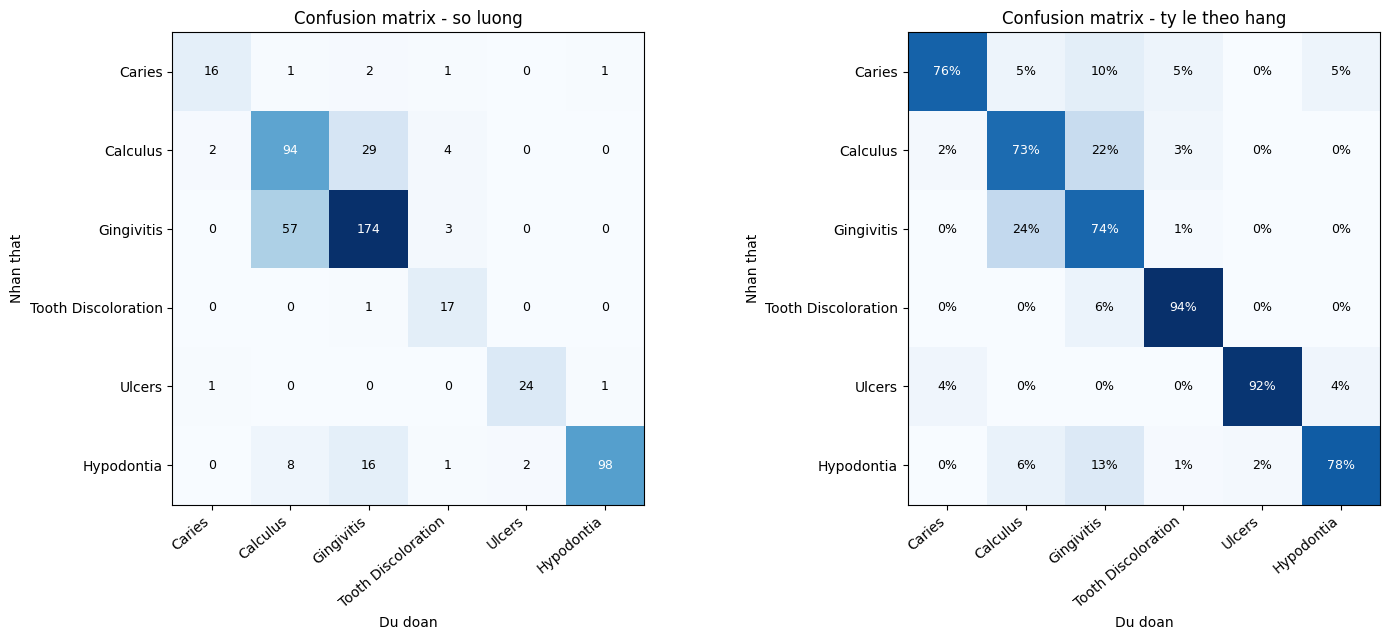

In [6]:
cm = confusion_matrix(y_true, y_pred, labels=range(len(CLASSIFIER_CLASSES)))
with np.errstate(invalid="ignore", divide="ignore"):
    cm_norm = np.nan_to_num(cm.astype(float) / cm.sum(axis=1, keepdims=True))

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
panels = [(axes[0], cm, "Confusion matrix - so luong", False), (axes[1], cm_norm, "Confusion matrix - ty le theo hang", True)]

for ax, matrix, title, is_ratio in panels:
    im = ax.imshow(matrix, cmap="Blues", vmin=0)
    ax.set_xticks(range(len(CLASSIFIER_CLASSES)))
    ax.set_yticks(range(len(CLASSIFIER_CLASSES)))
    ax.set_xticklabels(CLASSIFIER_CLASSES, rotation=40, ha="right")
    ax.set_yticklabels(CLASSIFIER_CLASSES)
    ax.set_xlabel("Du doan")
    ax.set_ylabel("Nhan that")
    ax.set_title(title)
    vmax = matrix.max() if matrix.max() > 0 else 1
    for i in range(len(CLASSIFIER_CLASSES)):
        for j in range(len(CLASSIFIER_CLASSES)):
            val = matrix[i, j]
            text = f"{val:.0%}" if is_ratio else f"{int(val)}"
            ax.text(j, i, text, ha="center", va="center", fontsize=9, color="white" if val > vmax / 2 else "black")

plt.tight_layout()
plt.show()

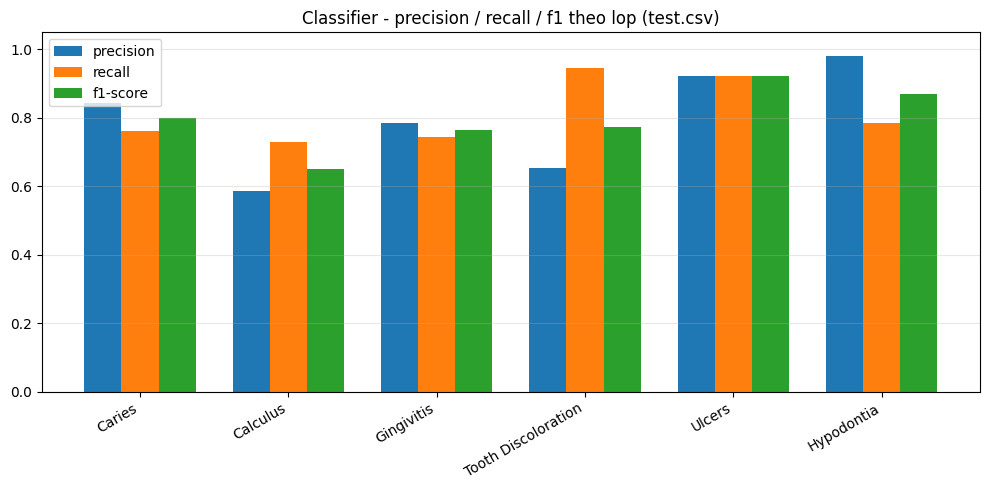

In [7]:
metric_names = ["precision", "recall", "f1-score"]
x = np.arange(len(CLASSIFIER_CLASSES))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, m in enumerate(metric_names):
    values = [report_dict[c][m] for c in CLASSIFIER_CLASSES]
    ax.bar(x + i * width, values, width, label=m)

ax.set_xticks(x + width)
ax.set_xticklabels(CLASSIFIER_CLASSES, rotation=30, ha="right")
ax.set_ylim(0, 1.05)
ax.set_title("Classifier - precision / recall / f1 theo lop (test.csv)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Detector - danh gia tren tap val (YOLOv8)

Nhac lai: day la tap da dung de chon `best.pt` luc train, khong phai tap test doc lap rieng.

In [8]:
eval_dir = ARTIFACTS_DIR / "eval_runs"
val_metrics = detector.model.val(
    data=str(ARTIFACTS_DIR / "dataset.yaml"), split="val",
    project=str(eval_dir), name="detector_val", exist_ok=True, verbose=False,
)

print(f"{'Lop':22s} {'Precision':>10s} {'Recall':>10s} {'mAP50':>8s} {'mAP50-95':>10s}")
for class_id, name in val_metrics.names.items():
    p, r = val_metrics.box.p[class_id], val_metrics.box.r[class_id]
    ap50, ap = val_metrics.box.ap50[class_id], val_metrics.box.ap[class_id]
    print(f"{name:22s} {p:10.3f} {r:10.3f} {ap50:8.3f} {ap:10.3f}")

print()
print(
    f"{'TRUNG BINH':22s} {val_metrics.box.mp:10.3f} {val_metrics.box.mr:10.3f} "
    f"{val_metrics.box.map50:8.3f} {val_metrics.box.map:10.3f}"
)

Ultralytics 8.4.112  Python-3.10.11 torch-2.13.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 178.3114.4 MB/s, size: 13.1 KB)
val: Scanning C:\lab-hackathon\dataset\yolo_bbox\labels\val.cache... 43 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 49/49  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.9it/s 2.1s0.4ss
                   all         49        164      0.883      0.852      0.923      0.595
Speed: 2.3ms preprocess, 6.9ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to C:\lab-hackathon\artifacts\eval_runs\detector_val
Lop                     Precision     Recall    mAP50   mAP50-95
Caries                      0.918      0.800    0.915      0.578
Ulcers                      0.923      1.000    0.995      0.751
Tooth Discoloration         0.892

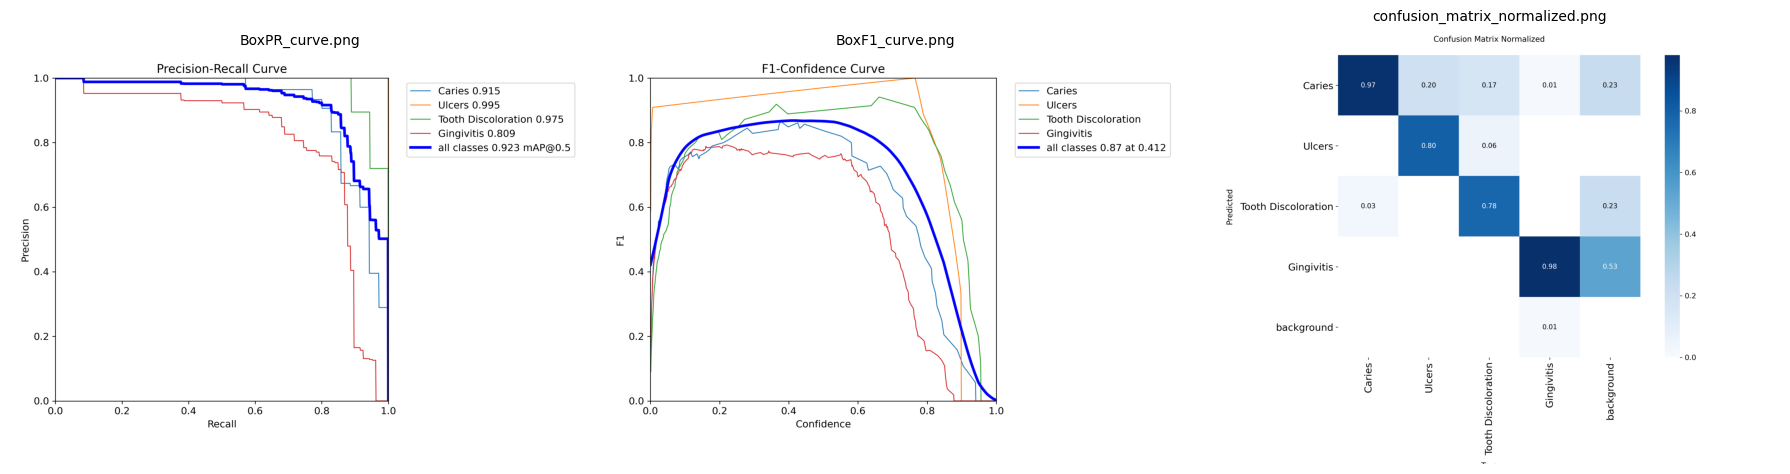

In [9]:
from PIL import Image

curve_files = ["BoxPR_curve.png", "BoxF1_curve.png", "confusion_matrix_normalized.png"]
available = [eval_dir / "detector_val" / f for f in curve_files if (eval_dir / "detector_val" / f).exists()]

if available:
    fig, axes = plt.subplots(1, len(available), figsize=(6 * len(available), 5.5))
    axes = [axes] if len(available) == 1 else axes
    for ax, path in zip(axes, available):
        ax.imshow(Image.open(path))
        ax.axis("off")
        ax.set_title(path.name, fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("Khong tim thay bieu do da sinh san.")